Loading weights: 100%|██████████| 392/392 [00:00<00:00, 7396.36it/s]


Number of layers: 25
Shape of middle layer 13: torch.Size([1, 197, 1024])


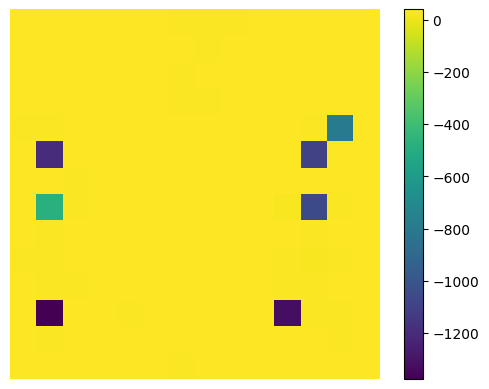

In [ ]:
import numpy as np
from os import listdir
from os.path import isfile, join
from sklearn.decomposition import PCA

from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import requests

# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# image = Image.open(requests.get(url, stream=True).raw)

variations_images = [f for f in listdir('images_variations') if isfile(join('images_variations', f))]


image = Image.open('faces_vase_color.jpg')


processor = ViTImageProcessor.from_pretrained('google/vit-large-patch16-224-in21k')
model = ViTModel.from_pretrained('google/vit-large-patch16-224-in21k')


inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs, output_hidden_states=True)

# hidden_states is a tuple of (embeddings + all layer outputs)
all_hidden_states = outputs.hidden_states

# Example: Totally 25 layers: take middle layer 13
# Totally 24 layers: take 12
if len(all_hidden_states) % 2:
    middle_layer_number = int((len(all_hidden_states) + 1 )/ 2)
else:
    middle_layer_number = int(len(all_hidden_states) / 2)
    # or maybe +1?
middle_layer_output = all_hidden_states[middle_layer_number]

print(f"Number of layers: {len(all_hidden_states)}")
print(f"Shape of middle layer {middle_layer_number}: {middle_layer_output.shape}")

last_hidden_state = outputs.last_hidden_state
X = middle_layer_output.detach().numpy()[0][1:,:] #Tensor with activations from the middle layer

pca = PCA(n_components=1)
X_reduced = pca.fit_transform(X)
# print(pca.explained_variance_ratio_)
# print(pca.singular_values_)
# # 1. Select the first component (eigenvector)
# first_component = pca.components_[0] # Shape: (n_features,)

# # 2. Project data (n_samples, 1) using the component
# X_reduced = pca.transform(X)[:, 0].reshape(-1, 1)

# # 3. Reconstruct: X_orig = (Reduced_Data * Components) + Mean
# # Note: Transpose first_component for matrix multiplication
# reconstruction = np.dot(X_reduced, first_component.reshape(1, -1)) + pca.mean_
doe_die_image = X_reduced.reshape(14,14)
plt.imshow(doe_die_image,cmap='viridis', interpolation=None)
plt.colorbar()
plt.legend('off')
plt.axis('off') # For the figure we don't need all the axis and legends
plt.savefig('image_output.jpg')
plt.show()


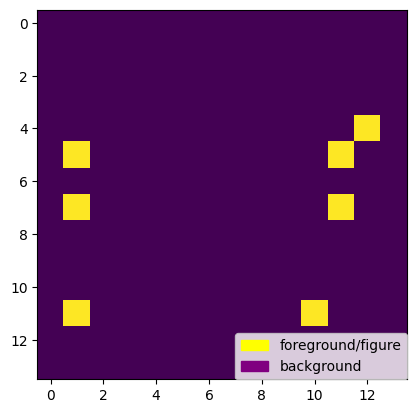

In [166]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

## color map and labels
t = 1 ## alpha value
cmap = {0:[1.0,1.0,0.0],1:[0.5,0.0,0.5]}
labels = {0:'foreground/figure',1:'background'}
arrayShow = np.where(
    doe_die_image < 0,
    1,
    0,)
## create patches as legend
patches =[mpatches.Patch(color=cmap[i],label=labels[i]) for i in cmap]

plt.imshow(arrayShow)
plt.legend(handles=patches, loc=4, borderaxespad=0.)
plt.show()


In [124]:
arrayShow

array([[0, 0, 1, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 1, 0],
       [1, 0, 1, ..., 0, 1, 1],
       ...,
       [0, 0, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(32, 32))